<a href="https://colab.research.google.com/github/NazHub1993/ML_Notebooks/blob/main/BankMarketingDataSet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [78]:
import numpy as np
import pandas as pd

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns


In [79]:
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.preprocessing import StandardScaler,MinMaxScaler,LabelEncoder,OneHotEncoder


from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier

from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.naive_bayes import BernoulliNB


In [80]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'bank-marketing-dataset' dataset.
Path to dataset files: /kaggle/input/bank-marketing-dataset


In [81]:
import os

# List files in the downloaded folder to find the CSV name
print(os.listdir(path))

['bank.csv']


In [82]:
df=pd.read_csv(os.path.join(path,'bank.csv'))
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


#Let's check the datatype of each column.

In [83]:
df.dtypes

,0
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object
day,int64


In [84]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


#**So there are no missing values**

#Let's analyze the target column first!!!

Text(0.5, 1.0, 'Distribution of Deposits')

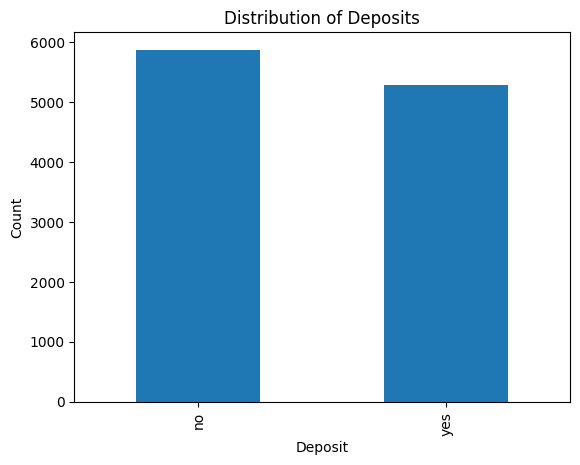

In [85]:
df['deposit'].value_counts().plot(kind='bar')
plt.xlabel('Deposit')
plt.ylabel('Count')
plt.title('Distribution of Deposits')

In [86]:
df['education'].value_counts()

,count
education,
secondary,5476
tertiary,3689
primary,1500
unknown,497


<Axes: xlabel='job'>

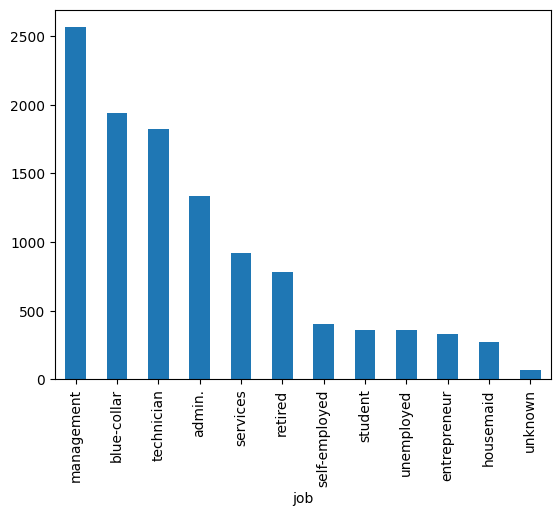

In [87]:
df['job'].value_counts().plot(kind='bar')


In [88]:
df['housing'].value_counts()

,count
housing,
no,5881
yes,5281


In [89]:
df['loan'].value_counts()

,count
loan,
no,9702
yes,1460


In [90]:
df['contact'].value_counts()

,count
contact,
cellular,8042
unknown,2346
telephone,774


In [91]:
df['poutcome'].value_counts()

,count
poutcome,
unknown,8326
failure,1228
success,1071
other,537


#So here label_encoding can only be applied to education column


In [92]:
le=LabelEncoder()
df['education']=le.fit_transform(df['education'])

In [93]:
df['education'].dtypes

dtype('int64')

In [94]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols = cat_cols.drop('deposit')
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [95]:
df.dtypes

,0
age,int64
education,int64
balance,int64
day,int64
duration,int64
campaign,int64
pdays,int64
previous,int64
deposit,object
job_blue-collar,bool


In [96]:
df.head()

,age,education,balance,day,duration,campaign,pdays,previous,deposit,job_blue-collar,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,59,1,2343,5,1042,1,-1,0,yes,False,...,False,False,False,True,False,False,False,False,False,True
1,56,1,45,5,1467,1,-1,0,yes,False,...,False,False,False,True,False,False,False,False,False,True
2,41,1,1270,5,1389,1,-1,0,yes,False,...,False,False,False,True,False,False,False,False,False,True
3,55,1,2476,5,579,1,-1,0,yes,False,...,False,False,False,True,False,False,False,False,False,True
4,54,2,184,5,673,2,-1,0,yes,False,...,False,False,False,True,False,False,False,False,False,True


In [97]:
df.columns

Index(['age', 'education', 'balance', 'day', 'duration', 'campaign', 'pdays',
       'previous', 'deposit', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_married', 'marital_single', 'default_yes',
       'housing_yes', 'loan_yes', 'contact_telephone', 'contact_unknown',
       'month_aug', 'month_dec', 'month_feb', 'month_jan', 'month_jul',
       'month_jun', 'month_mar', 'month_may', 'month_nov', 'month_oct',
       'month_sep', 'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')

In [98]:
len(df.columns)

41

In [99]:
sc=StandardScaler()
num_cols=df.select_dtypes(include='int64').columns
for col in num_cols:
  df[col]=sc.fit_transform(df[[col]])

In [100]:
df=df.drop('pdays',axis=1)

In [101]:
df['deposit'].dtypes

dtype('O')

In [102]:
df.dtypes

,0
age,float64
education,float64
balance,float64
day,float64
duration,float64
campaign,float64
previous,float64
deposit,object
job_blue-collar,bool
job_entrepreneur,bool


In [103]:
df['deposit']=df['deposit'].map({'no':0,'yes':1})

In [104]:
X=df.drop('deposit',axis=1)
Y=df['deposit']

#Train Test Split the data

In [105]:
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.3,random_state=42)

#Decision Tree  TEST

In [106]:
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': ['sqrt', 'log2', None]
}

dt_search=RandomizedSearchCV(
    estimator=DecisionTreeClassifier(),
    param_distributions=dt_param_grid,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    random_state=42
)

dt_search.fit(x_train,y_train)
dt_score=dt_search.best_score_
dt_best_params=dt_search.best_params_
dt_best_estimator=dt_search.best_estimator_


Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [107]:
dt_score

np.float64(0.8003317760339739)

In [108]:
dt_best_params

{'min_samples_split': 20,
 'min_samples_leaf': 1,
 'max_features': None,
 'max_depth': 20,
 'criterion': 'gini'}

#RandomForestClassifier Test

In [109]:
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

rf_search=RandomizedSearchCV(
    estimator=RandomForestClassifier(),
    param_distributions=rf_param_grid,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    random_state=42
)

rf_search.fit(x_train,y_train)
rf_score=rf_search.best_score_
rf_best_params=rf_search.best_params_
rf_best_estimator=rf_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [110]:
rf_score

np.float64(0.8553697336698607)

In [111]:
rf_best_params

{'n_estimators': 100,
 'min_samples_split': 5,
 'min_samples_leaf': 1,
 'max_features': 'sqrt',
 'max_depth': None,
 'bootstrap': True}

#Support Vector Classifier

In [112]:
svc_param_grid={
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'degree': [2, 3, 4]  # only used if kernel='poly'
}

svc_search=RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=svc_param_grid,
    n_iter=10,
    cv=5,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    random_state=42
)

svc_search.fit(x_train,y_train)
svc_score=svc_search.best_score_
svc_best_params=svc_search.best_params_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [113]:
svc_best_estimator=svc_search.best_estimator_

In [114]:
svc_score

np.float64(0.828235205451285)

#NaiveBayes Test

In [115]:
nb_param_grid = {
    'alpha': [0.01, 0.1, 0.5, 1.0, 2.0],
    'binarize': [0.0, 0.5, 1.0]  # threshold to convert continuous features to binary
}

nb_search=RandomizedSearchCV(
    estimator=BernoulliNB(),
    param_distributions=nb_param_grid,
    cv=5,
    n_iter=7,
    n_jobs=-1,
    verbose=1
)

nb_search.fit(x_train,y_train)
nb_score=nb_search.best_score_
nb_best_params=nb_search.best_params_
nb_best_estimator=nb_search.best_estimator_

Fitting 5 folds for each of 7 candidates, totalling 35 fits


In [116]:
nb_search.best_score_

np.float64(0.7484977918461738)

In [117]:
from sklearn.naive_bayes import GaussianNB

nb_param_grid = {
    'var_smoothing': [1e-11, 1e-10, 1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
}

nb = GaussianNB()
nb_search = RandomizedSearchCV(
    nb, param_distributions=nb_param_grid,
    n_iter=7, cv=5, scoring='accuracy', random_state=42, n_jobs=-1, verbose=1
)
nb_search.fit(x_train,y_train)

print("Best params:", nb_search.best_params_)
print("Best accuracy score:", nb_search.best_score_)

Fitting 5 folds for each of 7 candidates, totalling 35 fits
Best params: {'var_smoothing': 1e-05}
Best accuracy score: 0.7109943204858183


#XGB TEST

In [118]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.3, 0.5]
}

xgb_search=RandomizedSearchCV(
    estimator=XGBClassifier(),
    param_distributions=xgb_param_grid,
    cv=5,
    n_iter=10,
    scoring='accuracy',
    verbose=1
)

xgb_search.fit(x_train,y_train)
xgb_score=xgb_search.best_score_
xgb_params=xgb_search.best_params_
xgb_best_estimator=xgb_search.best_estimator_

Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [119]:
xgb_score

np.float64(0.8594641776091316)

In [120]:
xgb_params

{'subsample': 1.0,
 'n_estimators': 300,
 'max_depth': 9,
 'learning_rate': 0.05,
 'gamma': 0.3,
 'colsample_bytree': 0.8}

#So XGB performs the best!!!!!!!!!!!!!

In [121]:
Final_Model=xgb_best_estimator

In [122]:
Final_Model.fit(x_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=0.3, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=9,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [123]:
y_pred=Final_Model.predict(x_test)

In [124]:
y_proba=Final_Model.predict_proba(x_test)[:,1]

#Now evaluation of the Final Model

In [128]:
from sklearn.metrics import precision_score,recall_score,f1_score, roc_auc_score

In [129]:
print("Accuracy_Score: ",accuracy_score(y_test,y_pred))
print("Precision Score: ",precision_score(y_test,y_pred))
print("Recall Score: ",recall_score(y_test,y_pred))
print("F1 Score: ",f1_score(y_test,y_pred))

Accuracy_Score:  0.8507017020005972
Precision Score:  0.8246334310850439
Recall Score:  0.8749222153080274
F1 Score:  0.8490338164251208


In [130]:
print("ROC-AUC  :", roc_auc_score(y_test, y_proba))

print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC-AUC  : 0.9224035630568614

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.83      0.85      1742
           1       0.82      0.87      0.85      1607

    accuracy                           0.85      3349
   macro avg       0.85      0.85      0.85      3349
weighted avg       0.85      0.85      0.85      3349



In [132]:
from sklearn.metrics import roc_curve

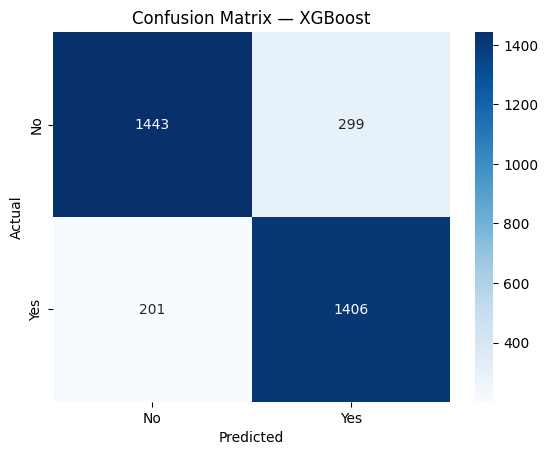

In [134]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — XGBoost')
plt.show()



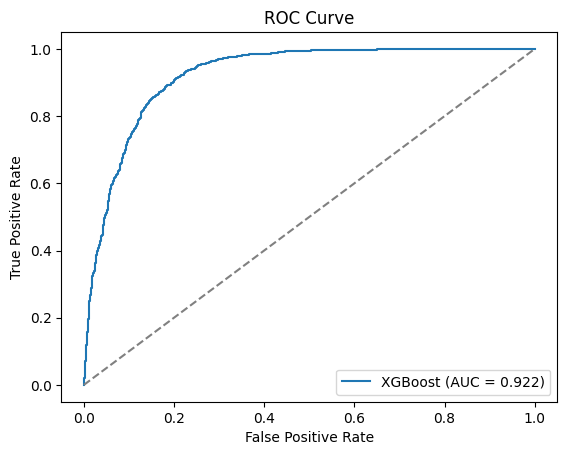

In [135]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba):.3f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [137]:
Final_Model.feature_importances_

array([0.01238815, 0.01109904, 0.01039947, 0.01443426, 0.05685337,
       0.01334766, 0.02845319, 0.0149343 , 0.00991751, 0.01010721,
       0.00831793, 0.00843747, 0.01041   , 0.00819487, 0.01571028,
       0.00826666, 0.00944967, 0.00761354, 0.00847503, 0.01109351,
       0.00845408, 0.04780373, 0.02161643, 0.00996771, 0.1102406 ,
       0.02993323, 0.01385292, 0.02156375, 0.02301263, 0.03028102,
       0.03314285, 0.06021198, 0.02952335, 0.02603918, 0.04041333,
       0.02797638, 0.01230481, 0.15068188, 0.02507697], dtype=float32)

In [138]:
x_train.columns

Index(['age', 'education', 'balance', 'day', 'duration', 'campaign',
       'previous', 'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
       'job_management', 'job_retired', 'job_self-employed', 'job_services',
       'job_student', 'job_technician', 'job_unemployed', 'job_unknown',
       'marital_married', 'marital_single', 'default_yes', 'housing_yes',
       'loan_yes', 'contact_telephone', 'contact_unknown', 'month_aug',
       'month_dec', 'month_feb', 'month_jan', 'month_jul', 'month_jun',
       'month_mar', 'month_may', 'month_nov', 'month_oct', 'month_sep',
       'poutcome_other', 'poutcome_success', 'poutcome_unknown'],
      dtype='object')

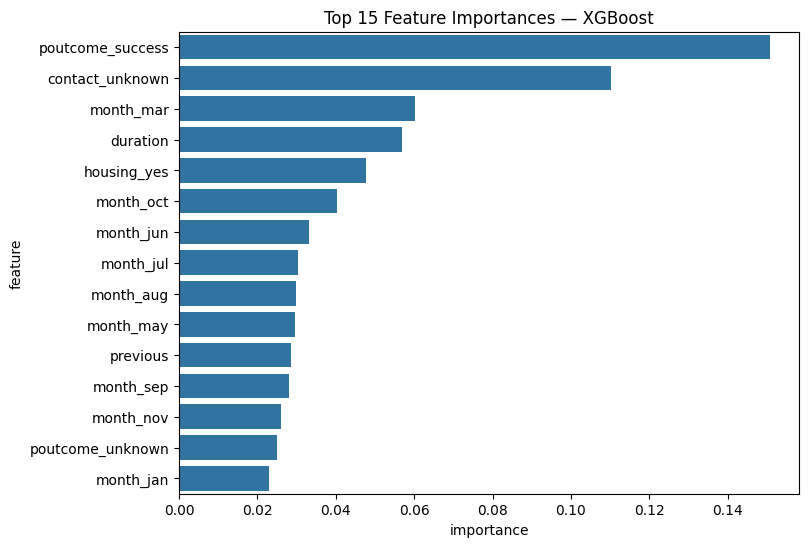

             feature  importance
37  poutcome_success    0.150682
24   contact_unknown    0.110241
31         month_mar    0.060212
4           duration    0.056853
21       housing_yes    0.047804
34         month_oct    0.040413
30         month_jun    0.033143
29         month_jul    0.030281
25         month_aug    0.029933
32         month_may    0.029523
6           previous    0.028453
35         month_sep    0.027976
33         month_nov    0.026039
38  poutcome_unknown    0.025077
28         month_jan    0.023013


In [136]:
importance_df = pd.DataFrame({
    'feature': x_train.columns,
    'importance': Final_Model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df.head(15), x='importance', y='feature')
plt.title('Top 15 Feature Importances — XGBoost')
plt.show()

print(importance_df.head(15))

In [140]:
print(Final_Model.feature_names_in_)

['age' 'education' 'balance' 'day' 'duration' 'campaign' 'previous'
 'job_blue-collar' 'job_entrepreneur' 'job_housemaid' 'job_management'
 'job_retired' 'job_self-employed' 'job_services' 'job_student'
 'job_technician' 'job_unemployed' 'job_unknown' 'marital_married'
 'marital_single' 'default_yes' 'housing_yes' 'loan_yes'
 'contact_telephone' 'contact_unknown' 'month_aug' 'month_dec' 'month_feb'
 'month_jan' 'month_jul' 'month_jun' 'month_mar' 'month_may' 'month_nov'
 'month_oct' 'month_sep' 'poutcome_other' 'poutcome_success'
 'poutcome_unknown']


In [141]:
import joblib

joblib.dump(Final_Model, 'xgb_bank_marketing_model.pkl')
joblib.dump(sc, 'scaler.pkl')
joblib.dump(x_train.columns.tolist(), 'model_columns.pkl')

print("Model, scaler, and column structure saved successfully.")

Model, scaler, and column structure saved successfully.


In [142]:
from sklearn.model_selection import cross_val_score,StratifiedKFold

skf=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

scores=cross_val_score(Final_Model,x_test,y_test,cv=skf,scoring='accuracy')

print(scores.mean())



0.8438332998683711
